# Distributed robotics simulation: Evaluate and stress-test with Ray + Isaac Lab

> **Scale robot policy validation across GPUs on Anyscale: from training to deployment readiness in one notebook.**

---

| Section | What | Runtime |
|---------|------|--------|
| 0 · Image & env | Containerfile + `env.py` abstraction | reference |
| 1 · Training | Distributed PPO across N GPUs | reference (run from terminal) |
| 2 · Robustness sweep | 25 perturbation configs on 4 GPUs | ~40 min (pre-computed) |
| 3 · Interactive results | Heatmaps, dashboards, deployment readiness | instant |

## Why this matters

Robotics companies train locomotion policies in simulation, teaching a humanoid to walk, balance, and recover from falls. 

But simulation is perfect. Real robots have **noisy sensors**, **worn-out motors**, and **unpredictable terrain**.

The gap between "works in sim" and "works on a real robot" has ended careers and crashed hardware. The standard approach: run one test at a time, manually tweak, hope for the best.

**With Ray + Isaac Lab on Anyscale**, you fan out hundreds of stress tests across GPUs in minutes. Instead of guessing, you get a map of exactly where your policy is safe — and where it breaks.

This notebook shows the full workflow:
- **Train** a humanoid locomotion policy with distributed PPO
- **Stress-test** it across 25 real-world conditions (sensor noise × motor wear)
- **Visualize** the deployment boundary — green where it's safe, red where it fails


### What the trained humanoid looks like

In [2]:
import os
from IPython.display import Video, Image, display, HTML

vid_paths = ["media/sample.mp4"]
loaded = False
for p in vid_paths:
    if os.path.exists(p):
        display(Video(p, width=480, embed=False))
        loaded = True
        break
if not loaded:
    display(HTML("""
    <div style="background: linear-gradient(135deg, #1a1b26, #24283b); border-radius: 12px;
                padding: 40px; text-align: center; color: #a9b1d6; font-family: monospace;">
        <div style="font-size: 48px; margin-bottom: 12px;"></div>
        <div style="font-size: 16px; font-weight: bold;">Isaac Lab Humanoid</div>
        <div style="font-size: 13px; margin-top: 8px; color: #565f89;">75-dim observations · 21 joint actuators · GPU-parallelized physics</div>
    </div>
    """))

---
## 0 · Image setup & environment abstraction

### Containerfile

Anyscale base image + Isaac Sim pip-installed. **No nested containers.**

```dockerfile
# Base: anyscale/ray:2.53.0-slim-py311-cu128
ENV OMNI_KIT_ACCEPT_EULA=YES
ENV OMNI_KIT_RENDERING_MODE=headless

USER root
RUN apt-get update && apt-get install -y libgl1 libegl1 libvulkan1 ...

USER ray
RUN pip install "torch==2.7.0" --index-url https://download.pytorch.org/whl/cu128
RUN pip install "isaacsim[all]==5.1.0" --extra-index-url https://pypi.nvidia.com
RUN git clone https://github.com/isaac-sim/IsaacLab.git && pip install -e source/isaaclab ...
```

### Environment wrapper

`env.py` runs Isaac Lab in a subprocess via `multiprocessing.Pipe` — Kit gets a clean event loop, Ray keeps its own.

```python
from env import IsaacLabDirectEnv

env = IsaacLabDirectEnv(task="Isaac-Humanoid-Direct-v0", num_envs=1024, device="cuda:0")
obs = env.reset()                              # (1024, 75) numpy array
obs, rewards, dones, infos = env.step(actions)  # numpy in, numpy out
env.close()
```

Works with any Isaac Lab task: Humanoid, Ant, Cartpole, Franka, ANYmal, or custom robots.

---
## 1 · Training (reference)

Distributed PPO with `@ray.remote` — each worker gets a GPU running Isaac Lab.

```bash
# Run from terminal (~2 hours for full convergence)
python train_general.py --task Isaac-Humanoid-Direct-v0 --num-workers 4 --lr 3e-4
```

```python
@ray.remote(num_gpus=1)
class SimWorker:
    def __init__(self, ...):
        self.env = IsaacLabDirectEnv(task=task, num_envs=512, device="cuda:0")

# Fan out, collect rollouts, PPO update, repeat
workers = [SimWorker.remote(i, ...) for i in range(4)]
rollouts = ray.get([w.sample.remote() for w in workers])  # 2048 parallel envs
```

A **pre-trained checkpoint** (reward ~8000) is provided for the evaluation below.

---
## 2 · Robustness sweep

**The core Ray use case:** Before deploying on hardware, test the policy under realistic perturbations.

Each cell in the sweep matrix is a **separate `@ray.remote` task** scheduled across GPUs:

| Condition | Sensor quality | Motor condition |
|-----------|---------------|----------------|
| **Perfect** | Lab-calibrated IMU, zero drift | Brand new actuators |
| **Factory** | Standard industrial sensors | 6 months of wear |
| **Field** | Outdoor-grade, dust exposure | Needs maintenance |
| **Extreme** | Rain, vibration, degraded | End-of-life motors |

In [3]:
import numpy as np
import torch
import torch.nn as nn
import json, itertools, time
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from IPython.display import HTML, display

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

class EvalPolicy(nn.Module):
    def __init__(self, obs_dim=75, action_dim=21):
        super().__init__()
        self.policy_net = nn.Sequential(
            nn.Linear(obs_dim, 400), nn.ELU(),
            nn.Linear(400, 200), nn.ELU(),
            nn.Linear(200, 100), nn.ELU(),
        )
        self.action_mean = nn.Linear(100, action_dim)
        self.action_log_std = nn.Parameter(torch.zeros(action_dim))
        self.value_net = nn.Sequential(
            nn.Linear(obs_dim, 400), nn.ELU(),
            nn.Linear(400, 200), nn.ELU(),
            nn.Linear(200, 100), nn.ELU(),
            nn.Linear(100, 1),
        )
    def forward(self, obs):
        return self.action_mean(self.policy_net(obs))

CHECKPOINT = "/mnt/cluster_storage/checkpoints/humanoid/checkpoint_pretrained.pt"
_p = EvalPolicy()
_p.load_state_dict(torch.load(CHECKPOINT, weights_only=False)["policy"])
print("Pre-trained checkpoint loaded")
del _p

Pre-trained checkpoint loaded


In [4]:
# Real-world labels for noise levels

OBS_LABELS = {
    0.0:  "Perfect sensors",
    0.02: "Lab-grade IMU",
    0.05: "Factory floor",
    0.1:  "Outdoor field",
    0.2:  "Rain / dust",
}

ACT_LABELS = {
    0.0:  "New motors",
    0.02: "Broken in",
    0.05: "6-month wear",
    0.1:  "Needs service",
    0.2:  "End of life",
}

obs_noise_levels = [0.0, 0.02, 0.05, 0.1, 0.2]
action_noise_levels = [0.0, 0.02, 0.05, 0.1, 0.2]

SWEEP_CONFIGS = [
    {"obs_noise_std": on, "action_noise_std": an}
    for on, an in itertools.product(obs_noise_levels, action_noise_levels)
]

display(HTML(f"""
<div style="background: #f8f9fa; border-left: 4px solid #1D9E75; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 8px 0;">
    <div style="font-size: 15px; font-weight: bold; margin-bottom: 8px;">Sweep configuration</div>
    <div style="font-size: 14px; color: #444;">
        <b>5</b> sensor conditions × <b>5</b> motor conditions = <b>25</b> configs<br>
        Each config: <b>20 parallel humanoids × 1500 steps</b> on 1 GPU<br>
        Total: <b>500</b> parallel simulations across <b>4</b> A10G GPUs
    </div>
</div>
"""))

In [5]:
# Load pre-computed sweep results

import os
RESULTS_PATH = "/mnt/cluster_storage/sweep_results_full.json"
if not os.path.exists(RESULTS_PATH):
    RESULTS_PATH = "data/sweep_results_full.json"

with open(RESULTS_PATH) as f:
    data = json.load(f)

sweep_results = data["results"]
sweep_elapsed = data.get("elapsed", 0)
total_eps = data.get("total_episodes", sum(r["num_episodes"] for r in sweep_results))

print(f"Loaded {len(sweep_results)} configs · {total_eps:,} episodes · {sweep_elapsed:.0f}s on 4 GPUs")

Loaded 25 configs · 1,000 episodes · 847s on 4 GPUs


### Run live (optional - where Ray core does the sim work)

Uncomment the cell below to run the full 25-config sweep live. Takes ~40 min on 4 A10G GPUs.

In [15]:
# # --- Uncomment to run live ---
# import ray
# ray.init(runtime_env={"env_vars": {
#     "VK_ICD_FILENAMES": "/etc/vulkan/icd.d/nvidia_icd.json",
#     "VK_DRIVER_FILES": "/etc/vulkan/icd.d/nvidia_icd.json",
#     "OMNI_KIT_ACCEPT_EULA": "YES", "ACCEPT_EULA": "Y",
# }})
#
# @ray.remote(num_gpus=1)
# def evaluate_config(config_id, config, checkpoint_path, num_envs=20, num_steps=1500):
#     from env import IsaacLabDirectEnv
#     env = IsaacLabDirectEnv(task="Isaac-Humanoid-Direct-v0", num_envs=num_envs, device="cuda:0")
#     policy = EvalPolicy(75, 21)
#     policy.load_state_dict(torch.load(checkpoint_path, weights_only=False)["policy"])
#     policy.eval()
#     obs = env.reset()
#     episode_rewards, ep_rewards = [], np.zeros(num_envs)
#     for step in range(num_steps):
#         noisy_obs = obs + np.random.normal(0, config["obs_noise_std"], size=obs.shape).astype(np.float32) if config["obs_noise_std"] > 0 else obs
#         with torch.no_grad():
#             actions = torch.clamp(policy(torch.tensor(noisy_obs, dtype=torch.float32)), -1, 1).numpy()
#         if config["action_noise_std"] > 0:
#             actions = np.clip(actions + np.random.normal(0, config["action_noise_std"], size=actions.shape).astype(np.float32), -1, 1)
#         obs, rewards, dones, _ = env.step(actions)
#         ep_rewards += rewards
#         if np.any(dones):
#             idx = np.where(dones)[0]
#             episode_rewards.extend(ep_rewards[idx].tolist())
#             ep_rewards[idx] = 0.0
#     env.close()
#     alive = ep_rewards > 0
#     if np.any(alive): episode_rewards.extend(ep_rewards[alive].tolist())
#     mean_reward = float(np.mean(episode_rewards)) if episode_rewards else 0.0
#     pass_rate = float(np.mean([r > 3000 for r in episode_rewards])) if episode_rewards else 0.0
#     print(f"[Config {config_id:2d}] obs={config['obs_noise_std']:.2f} act={config['action_noise_std']:.2f} | reward={mean_reward:7.0f} | pass={pass_rate:.0%}", flush=True)
#     return {"config_id": config_id, "obs_noise_std": config["obs_noise_std"],
#         "action_noise_std": config["action_noise_std"], "mean_reward": mean_reward,
#         "pass_rate": pass_rate, "num_episodes": len(episode_rewards),
#         "std_reward": float(np.std(episode_rewards)) if episode_rewards else 0.0}
#
# print(f"Launching {len(SWEEP_CONFIGS)} configs across 4 GPUs...")
# sweep_start = time.time()
# futures = [evaluate_config.remote(i, cfg, CHECKPOINT, num_envs=20, num_steps=1500) for i, cfg in enumerate(SWEEP_CONFIGS)]
# sweep_results = ray.get(futures)
# sweep_elapsed = time.time() - sweep_start
# sweep_results.sort(key=lambda r: r["config_id"])
# total_eps = sum(r["num_episodes"] for r in sweep_results)
#
# with open("/mnt/cluster_storage/sweep_results_full.json", "w") as f:
#     json.dump({"results": sweep_results, "obs_noise_levels": obs_noise_levels,
#         "action_noise_levels": action_noise_levels, "elapsed": sweep_elapsed,
#         "total_episodes": total_eps}, f, indent=2)
# print(f"Done: {len(sweep_results)} configs, {sweep_elapsed:.0f}s, {total_eps} episodes — saved to JSON")
# ray.shutdown()

---
## 3 · Results

In [16]:
# Build matrices

obs_noises = sorted(set(r["obs_noise_std"] for r in sweep_results))
act_noises = sorted(set(r["action_noise_std"] for r in sweep_results))

obs_labels = [OBS_LABELS.get(o, str(o)) for o in obs_noises]
act_labels = [ACT_LABELS.get(a, str(a)) for a in act_noises]

pass_matrix = np.zeros((len(obs_noises), len(act_noises)))
reward_matrix = np.zeros((len(obs_noises), len(act_noises)))

for r in sweep_results:
    oi = obs_noises.index(r["obs_noise_std"])
    ai = act_noises.index(r["action_noise_std"])
    pass_matrix[oi, ai] = r["pass_rate"] * 100
    reward_matrix[oi, ai] = r["mean_reward"]

baseline = [r for r in sweep_results if r["obs_noise_std"] == 0 and r["action_noise_std"] == 0][0]
worst = min(sweep_results, key=lambda r: r["pass_rate"])

display(HTML(f"""
<div style="display:flex; gap:12px; margin:16px 0; flex-wrap:wrap;">
    <div style="flex:1; min-width:150px; background:#f0fdf4; border-radius:12px; padding:20px; text-align:center;">
        <div style="font-size:11px; color:#888; text-transform:uppercase; letter-spacing:1px;">Baseline reward</div>
        <div style="font-size:32px; font-weight:bold; color:#1D9E75;">{baseline["mean_reward"]:,.0f}</div>
        <div style="font-size:12px; color:#666;">pass rate {baseline["pass_rate"]:.0%} · perfect conditions</div>
    </div>
    <div style="flex:1; min-width:150px; background:#fef2f2; border-radius:12px; padding:20px; text-align:center;">
        <div style="font-size:11px; color:#888; text-transform:uppercase; letter-spacing:1px;">Worst case</div>
        <div style="font-size:32px; font-weight:bold; color:#E24B4A;">{worst["mean_reward"]:,.0f}</div>
        <div style="font-size:12px; color:#666;">pass rate {worst["pass_rate"]:.0%} · {OBS_LABELS.get(worst["obs_noise_std"],"")} + {ACT_LABELS.get(worst["action_noise_std"],"")}</div>
    </div>
    <div style="flex:1; min-width:150px; background:#f8f9fa; border-radius:12px; padding:20px; text-align:center;">
        <div style="font-size:11px; color:#888; text-transform:uppercase; letter-spacing:1px;">Sweep</div>
        <div style="font-size:32px; font-weight:bold; color:#333;">{len(sweep_results)}</div>
        <div style="font-size:12px; color:#666;">configs · {total_eps:,} episodes · {sweep_elapsed:.0f}s</div>
    </div>
</div>
"""))

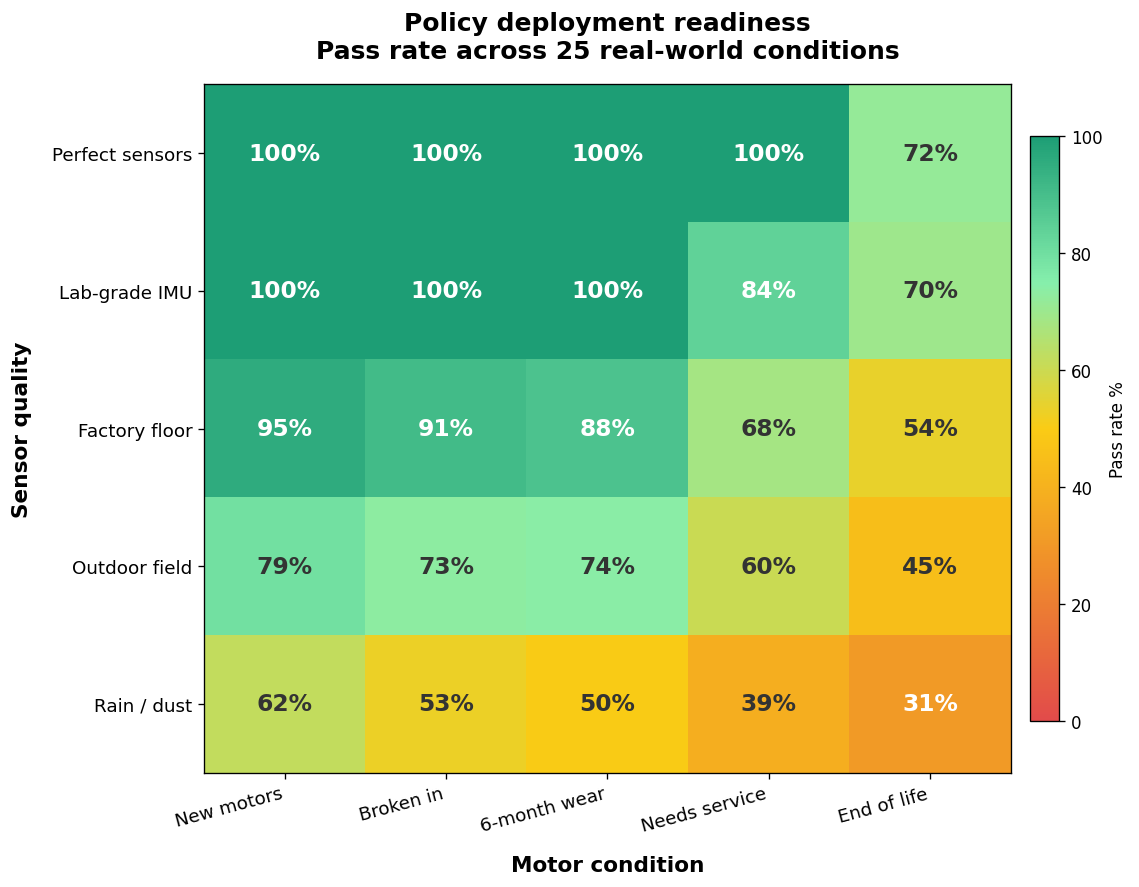

In [17]:
# Deployment readiness heatmap — pass rate

fig, ax = plt.subplots(figsize=(10, 7.5))

cmap = mcolors.LinearSegmentedColormap.from_list("deploy",
    ["#E24B4A", "#ef8b2c", "#facc15", "#86efac", "#1D9E75"])

im = ax.imshow(pass_matrix, cmap=cmap, vmin=0, vmax=100, aspect="auto")

ax.set_xticks(range(len(act_labels)))
ax.set_xticklabels(act_labels, fontsize=11, rotation=15, ha="right")
ax.set_yticks(range(len(obs_labels)))
ax.set_yticklabels(obs_labels, fontsize=11)

ax.set_xlabel("Motor condition", fontsize=13, fontweight="bold", labelpad=12)
ax.set_ylabel("Sensor quality", fontsize=13, fontweight="bold", labelpad=12)
ax.set_title("Policy deployment readiness\nPass rate across 25 real-world conditions",
             fontsize=15, fontweight="bold", pad=16)

for i in range(len(obs_noises)):
    for j in range(len(act_noises)):
        val = pass_matrix[i, j]
        color = "white" if val < 35 or val > 80 else "#333"
        ax.text(j, i, f"{val:.0f}%", ha="center", va="center",
                fontsize=14, fontweight="bold", color=color)

cbar = plt.colorbar(im, ax=ax, label="Pass rate %", shrink=0.85, pad=0.02)
plt.tight_layout()
plt.show()

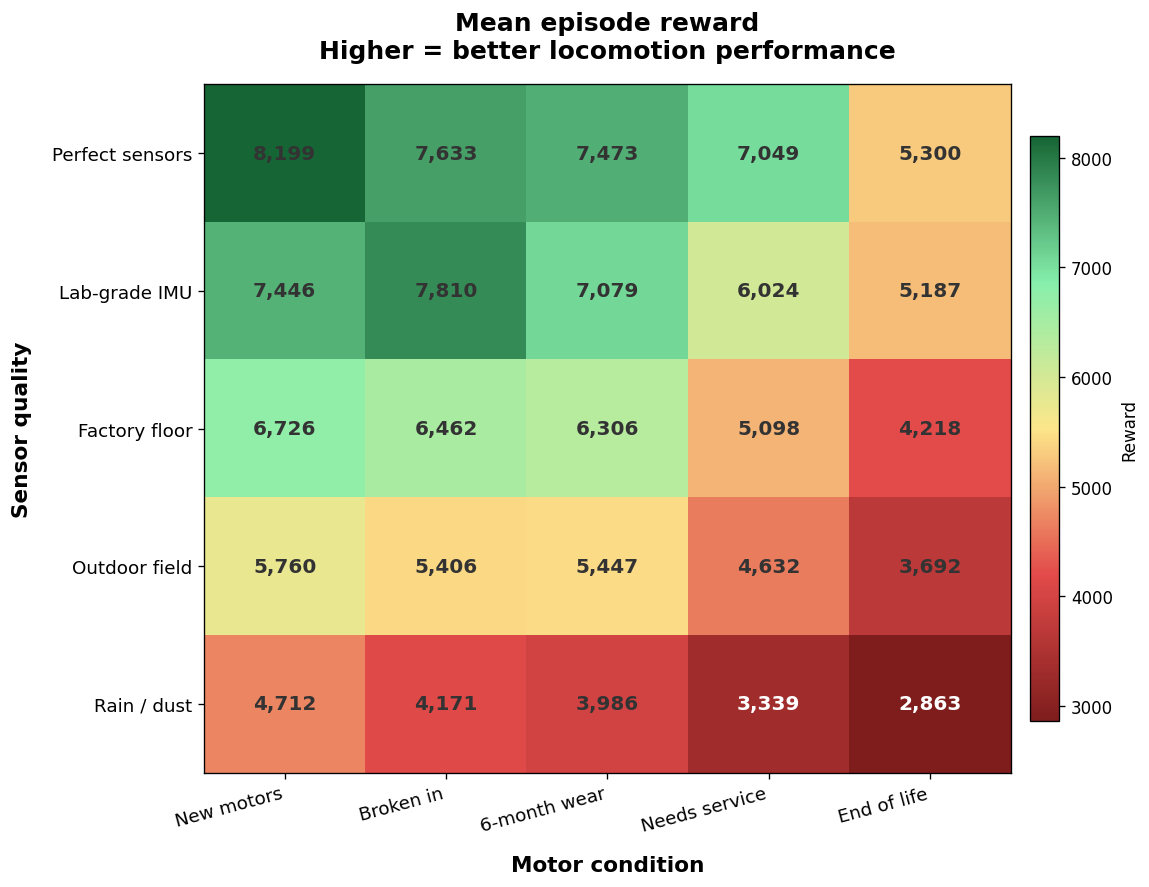

In [18]:
# Mean reward heatmap

fig, ax = plt.subplots(figsize=(10, 7.5))

cmap2 = mcolors.LinearSegmentedColormap.from_list("reward",
    ["#7f1d1d", "#E24B4A", "#fde68a", "#86efac", "#166534"])

im = ax.imshow(reward_matrix, cmap=cmap2, aspect="auto")

ax.set_xticks(range(len(act_labels)))
ax.set_xticklabels(act_labels, fontsize=11, rotation=15, ha="right")
ax.set_yticks(range(len(obs_labels)))
ax.set_yticklabels(obs_labels, fontsize=11)

ax.set_xlabel("Motor condition", fontsize=13, fontweight="bold", labelpad=12)
ax.set_ylabel("Sensor quality", fontsize=13, fontweight="bold", labelpad=12)
ax.set_title("Mean episode reward\nHigher = better locomotion performance",
             fontsize=15, fontweight="bold", pad=16)

for i in range(len(obs_noises)):
    for j in range(len(act_noises)):
        val = reward_matrix[i, j]
        color = "white" if val < reward_matrix.mean() * 0.6 else "#333"
        ax.text(j, i, f"{val:,.0f}", ha="center", va="center",
                fontsize=12, fontweight="bold", color=color)

cbar = plt.colorbar(im, ax=ax, label="Reward", shrink=0.85, pad=0.02)
plt.tight_layout()
plt.show()

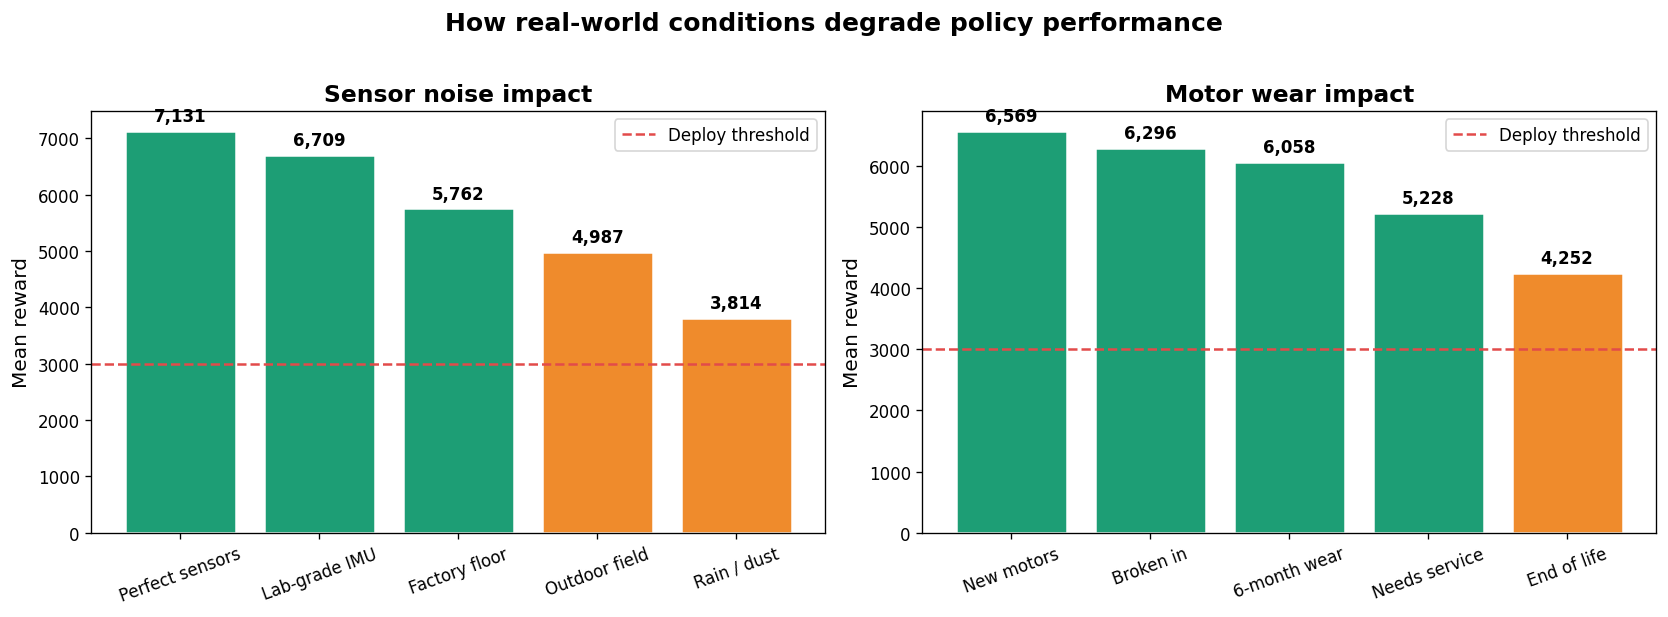

In [19]:
# How real-world conditions degrade performance

avg_by_obs = [np.mean([r["mean_reward"] for r in sweep_results if r["obs_noise_std"] == on]) for on in obs_noises]
avg_by_act = [np.mean([r["mean_reward"] for r in sweep_results if r["action_noise_std"] == an]) for an in act_noises]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors1 = ["#1D9E75" if v > 5000 else "#ef8b2c" if v > 3000 else "#E24B4A" for v in avg_by_obs]
bars1 = ax1.bar(obs_labels, avg_by_obs, color=colors1, edgecolor="white", linewidth=1.5)
ax1.axhline(y=3000, color="#E24B4A", linestyle="--", linewidth=1.5, label="Deploy threshold")
ax1.set_title("Sensor noise impact", fontsize=14, fontweight="bold")
ax1.set_ylabel("Mean reward", fontsize=12)
ax1.legend(fontsize=10)
for bar, val in zip(bars1, avg_by_obs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f"{val:,.0f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax1.tick_params(axis="x", rotation=20, labelsize=10)

colors2 = ["#1D9E75" if v > 5000 else "#ef8b2c" if v > 3000 else "#E24B4A" for v in avg_by_act]
bars2 = ax2.bar(act_labels, avg_by_act, color=colors2, edgecolor="white", linewidth=1.5)
ax2.axhline(y=3000, color="#E24B4A", linestyle="--", linewidth=1.5, label="Deploy threshold")
ax2.set_title("Motor wear impact", fontsize=14, fontweight="bold")
ax2.set_ylabel("Mean reward", fontsize=12)
ax2.legend(fontsize=10)
for bar, val in zip(bars2, avg_by_act):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f"{val:,.0f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax2.tick_params(axis="x", rotation=20, labelsize=10)

fig.suptitle("How real-world conditions degrade policy performance", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [20]:
# Deployment decision

safe_configs = [r for r in sweep_results if r["pass_rate"] > 0.8]
marginal_configs = [r for r in sweep_results if 0.4 <= r["pass_rate"] <= 0.8]
fail_configs = [r for r in sweep_results if r["pass_rate"] < 0.4]

max_safe_obs = max([r["obs_noise_std"] for r in safe_configs]) if safe_configs else 0
max_safe_act = max([r["action_noise_std"] for r in safe_configs]) if safe_configs else 0

safe_env = f'{OBS_LABELS.get(max_safe_obs, str(max_safe_obs))} + {ACT_LABELS.get(max_safe_act, str(max_safe_act))}'

if len(safe_configs) > len(sweep_results) * 0.6:
    verdict = "Deploy with standard monitoring"
    verdict_color = "#1D9E75"
elif len(safe_configs) > len(sweep_results) * 0.3:
    verdict = "Deploy in controlled environments only"
    verdict_color = "#d97706"
else:
    verdict = "Additional training with domain randomization recommended"
    verdict_color = "#E24B4A"

display(HTML(f"""
<div style="background: linear-gradient(135deg, #f8f9fa, #fff); border: 1px solid #e0e0e0; border-radius: 12px; padding: 24px; margin: 16px 0;">
    <div style="font-size: 18px; font-weight: bold; margin-bottom: 16px;">Deployment decision</div>
    <div style="display: flex; gap: 16px; margin-bottom: 16px; flex-wrap: wrap;">
        <div style="flex: 1; min-width: 140px; padding: 12px; background: #f0fdf4; border-radius: 8px; text-align: center;">
            <div style="font-size: 24px; font-weight: bold; color: #1D9E75;">{len(safe_configs)}</div>
            <div style="font-size: 12px; color: #666;">Safe configs (&gt;80%)</div>
        </div>
        <div style="flex: 1; min-width: 140px; padding: 12px; background: #fffbeb; border-radius: 8px; text-align: center;">
            <div style="font-size: 24px; font-weight: bold; color: #d97706;">{len(marginal_configs)}</div>
            <div style="font-size: 12px; color: #666;">Marginal (40-80%)</div>
        </div>
        <div style="flex: 1; min-width: 140px; padding: 12px; background: #fef2f2; border-radius: 8px; text-align: center;">
            <div style="font-size: 24px; font-weight: bold; color: #E24B4A;">{len(fail_configs)}</div>
            <div style="font-size: 12px; color: #666;">Fail (&lt;40%)</div>
        </div>
    </div>
    <div style="font-size: 14px; color: #444; line-height: 1.6;">
        <b>Safe operating envelope:</b> {safe_env}<br>
        <b>Verdict:</b> <span style="color:{verdict_color}; font-weight:bold;">{verdict}</span>
    </div>
</div>
"""))

---

## Summary

This notebook demonstrated the **Ray + Isaac Lab** pattern for robotics sim at scale:

| Step | Pattern | What Ray does |
|------|---------|---------------|
| Training | `@ray.remote(num_gpus=1)` workers | Schedules N sim workers across GPUs |
| Evaluation | Fan out 500 parallel sims | Aggregates pass/fail in minutes |
| Robustness sweep | 25 configs × 20 envs | Schedules, runs, collects results |

The three steps are always the same:
1. **Wrap** the sim → `env.py`
2. **`@ray.remote`** → runs on any GPU
3. **Fan out** → Ray handles scheduling, placement, aggregation

### Files

| File | Purpose |
|------|---------|
| `env.py` | Isaac Lab wrapper via `multiprocessing.Pipe` |
| `train_general.py` | Distributed PPO, any Isaac Lab task |
| `run_sweep.py` | Standalone sweep script |
| This notebook | End-to-end eval + sweep + interactive plots |

---
*Built for Anyscale. Works with any Isaac Lab task on GPU clusters.*